In [19]:
import pandas as pd

ecomsa_df = pd.read_csv("ECOMSA.csv")

ecomsa_df.head()
ecomsa_df.info()
ecomsa_df.describe()
ecomsa_df.shape

ecomsa_df.isnull().sum()

ecomsa_df.duplicated().sum()

ecomsa_df["observation_date"] = pd.to_datetime(ecomsa_df["observation_date"])

ecomsa_df.rename(columns={
    "observation_date": "Quarter",
    "ECOMSA": "Ecommerce_Sales_Millions"
}, inplace=True)

ecomsa_df["Year"] = ecomsa_df["Quarter"].dt.year
ecomsa_df["Quarter_Num"] = ecomsa_df["Quarter"].dt.quarter

def covid_period(year):
    if year == 2019:
        return "Pre-COVID"
    elif year <= 2022:
        return "COVID"
    else:
        return "Post-COVID"

ecomsa_df["COVID_Period"] = ecomsa_df["Year"].apply(covid_period)

clean_ecomsa_df = ecomsa_df.copy()

clean_ecomsa_df.head()
clean_ecomsa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   observation_date  29 non-null     object
 1   ECOMSA            29 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 592.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Quarter                   29 non-null     datetime64[ns]
 1   Ecommerce_Sales_Millions  29 non-null     int64         
 2   Year                      29 non-null     int64         
 3   Quarter_Num               29 non-null     int64         
 4   COVID_Period              29 non-null     object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.3+ KB


In [20]:
import pandas as pd
import numpy as np

census_df = pd.read_excel("supecommerce4541 (1).xlsx", header=[3, 4])

census_df.head()
census_df.info()
census_df.describe(include="all")
census_df.shape

census_df.isnull().sum()

census_df.duplicated().sum()

census_df.columns = [
    "_".join([str(level) for level in col if pd.notna(level)]).strip()
    for col in census_df.columns.values
]

census_df.rename(columns={
    census_df.columns[0]: "NAICS_Code",
    census_df.columns[1]: "Business_Category"
}, inplace=True)

census_df = census_df.dropna(subset=["Business_Category"])

census_df["Business_Category"] = census_df["Business_Category"].str.strip()

suppression_codes = ["D", "S", "Z", "ZZ"]

census_df = census_df.mask(census_df.isin(suppression_codes), np.nan)

census_df.columns = census_df.columns.str.replace("r_", "_", regex=False)

census_df["NAICS_Code"] = pd.to_numeric(
    census_df["NAICS_Code"],
    errors="coerce"
)

numeric_columns = census_df.columns[2:]

census_df[numeric_columns] = census_df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

census_df.isnull().sum()

census_df.duplicated().sum()

clean_census_df = census_df.copy()

clean_census_df.head()
clean_census_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 18 columns):
 #   Column                                                          Non-Null Count  Dtype 
---  ------                                                          --------------  ----- 
 0   (NAICS Code of Primary Business Activity3, Unnamed: 0_level_1)  25 non-null     object
 1   (NAICS Code of Primary Business Activity3, Kind of Business )   13 non-null     object
 2   (2022, Total)                                                   13 non-null     object
 3   (2022, E-commerce)                                              13 non-null     object
 4   (2021r, Total)                                                  13 non-null     object
 5   (2021r, E-commerce)                                             13 non-null     object
 6   (2020r, Total)                                                  13 non-null     object
 7   (2020r, E-commerce)                                             

In [21]:
ecommerce_long_df = clean_census_df.melt(
    id_vars=["NAICS_Code", "Business_Category"],
    value_vars=[col for col in clean_census_df.columns if "E-commerce" in col],
    var_name="Year",
    value_name="Category_Ecommerce_Sales"
)

ecommerce_long_df["Year"] = (
    ecommerce_long_df["Year"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

annual_fred = (
    clean_ecomsa_df.groupby("Year", as_index=False)["Ecommerce_Sales_Millions"]
    .sum()
)

merged_df = ecommerce_long_df.merge(
    annual_fred,
    on="Year",
    how="left"
)

print("Merged Dataset Preview:")
print(merged_df.head(10))

Merged Dataset Preview:
   NAICS_Code                                  Business_Category  Year  \
0         NaN  Total Electronic Shopping and Mail-Order House...  2022   
1       441.0  Motor vehicle and parts dealers …………………………...…...  2022   
2       442.0  Furniture and home furnishings stores ……………………...  2022   
3       443.0  Electronics and appliance stores …………………………......  2022   
4       444.0  Building material and garden equipment and sup...  2022   
5       445.0  Food and beverage stores …………………………...……………………...  2022   
6       446.0  Health and personal care stores …………………………...…...  2022   
7       447.0  Gasoline stations …………………………...……………………………………....  2022   
8       448.0  Clothing and clothing accessories stores ……………...  2022   
9       451.0  Sporting goods, hobby, musical instrument, and...  2022   

   Category_Ecommerce_Sales  Ecommerce_Sales_Millions  
0                  870459.0                  996589.0  
1                       NaN                  9965

In [22]:
print("\nMerged Dataset Shape:")
print(merged_df.shape)

print("\nMerged Dataset Columns:")
print(merged_df.columns.tolist())

print("FRED Years:")
print(sorted(clean_ecomsa_df["Year"].unique()))

print("\nCensus Years:")
print(sorted(ecommerce_long_df["Year"].unique()))

print("\nMerged Years:")
print(sorted(merged_df["Year"].unique()))


Merged Dataset Shape:
(104, 5)

Merged Dataset Columns:
['NAICS_Code', 'Business_Category', 'Year', 'Category_Ecommerce_Sales', 'Ecommerce_Sales_Millions']
FRED Years:
[2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

Census Years:
[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

Merged Years:
[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


This time series chart shows the dollar amount in millions of money spent on e-commerce. The y-axis shows the amount of money spent in the millions per year on the x-axis. The years span from 2019 - 2006. The years are shaded to show clearly green is for the years before covid, red is for during and blue is for after. It is very clear that the e-commerce amounts jumped right at the beginning of the COVID section, the amount keeps rising steadily throuought and past COVID.

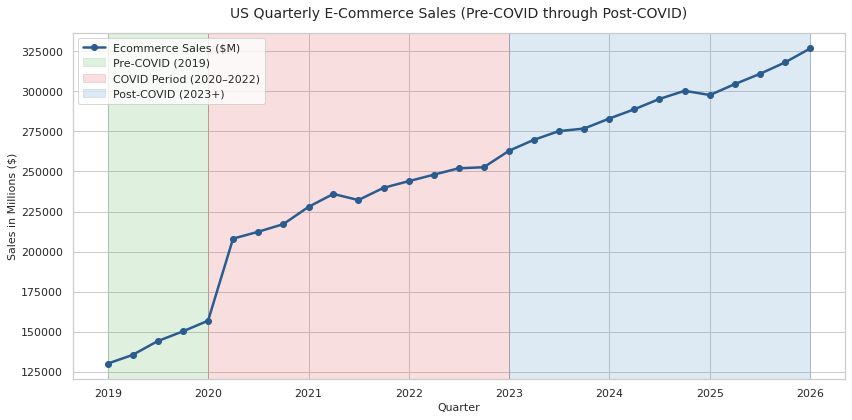

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot quarterly e-commerce sales line
plt.plot(
    clean_ecomsa_df["Quarter"],
    clean_ecomsa_df["Ecommerce_Sales_Millions"],
    marker="o",
    color="#2b5c8f",
    linewidth=2.5,
    label="Ecommerce Sales ($M)",
)

# Highlight periods with background shading
plt.axvspan(
    pd.Timestamp("2019-01-01"),
    pd.Timestamp("2019-12-31"),
    color="#2ca02c",
    alpha=0.15,
    label="Pre-COVID (2019)",
)

plt.axvspan(
    pd.Timestamp("2020-01-01"),
    pd.Timestamp("2022-12-31"),
    color="#d62728",
    alpha=0.15,
    label="COVID Period (2020–2022)",
)

max_date = clean_ecomsa_df["Quarter"].max()
if max_date >= pd.Timestamp("2023-01-01"):
    plt.axvspan(
        pd.Timestamp("2023-01-01"),
        max_date,
        color="#1f77b4",
        alpha=0.15,
        label="Post-COVID (2023+)",
    )

# Formatting labels and title
plt.title(
    "US Quarterly E-Commerce Sales (Pre-COVID through Post-COVID)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Quarter", fontsize=11)
plt.ylabel("Sales in Millions ($)", fontsize=11)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

In the bellow cell, I sorted the amount of money spent on e-commerc by category to use for the next model.

In [28]:
# Recreate df_categories from the merged wide/long dataset
df_categories = merged_df.pivot(
    index=["NAICS_Code", "Business_Category"],
    columns="Year",
    values="Category_Ecommerce_Sales",
).reset_index()

# Rename year columns to match the code expectations
df_categories.columns.name = None
df_categories = df_categories.rename(
    columns={2019: "2019_E-commerce", 2020: "2020_E-commerce"}
)

In this bar chart, I want to see what product category had the biggest jump in the early stage of COVID. One bar for each category represents the difference in the e-commerce amounts before and after covid. The numbers are not so representative as they aren't percentages.

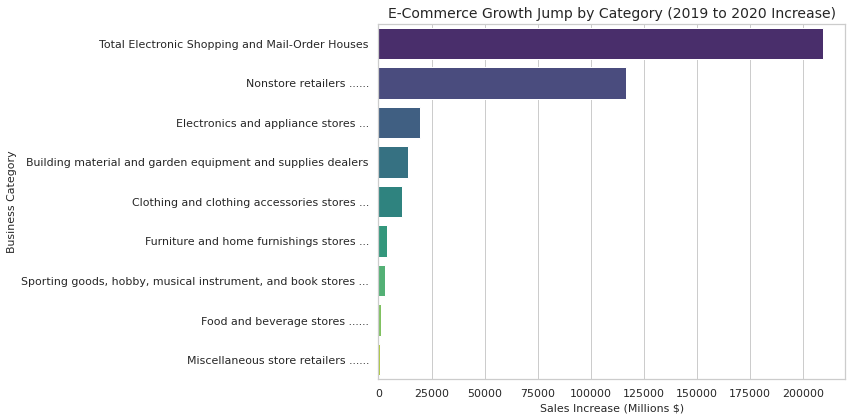

In [29]:
# Clean up strings if not performed in a previous step
df_categories["Business_Category_Clean"] = (
    df_categories["Business_Category"]
    .str.replace("…", "", regex=False)
    .str.strip()
)

# Calculate absolute jump (2020 vs 2019)
df_categories["COVID_Jump_2020"] = (
    df_categories["2020_E-commerce"] - df_categories["2019_E-commerce"]
)

# Sort by largest jump
df_sorted = df_categories.dropna(subset=["COVID_Jump_2020"]).sort_values(
    by="COVID_Jump_2020", ascending=False
)

# Initialize figure BEFORE plotting
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_sorted,
    x="COVID_Jump_2020",
    y="Business_Category_Clean",
    palette="viridis",
)

plt.title(
    "E-Commerce Growth Jump by Category (2019 to 2020 Increase)", fontsize=14
)
plt.xlabel("Sales Increase (Millions $)", fontsize=11)
plt.ylabel("Business Category", fontsize=11)
plt.tight_layout()
plt.show()

In [26]:
print(merged_df)

     NAICS_Code                                  Business_Category  Year  \
0           NaN  Total Electronic Shopping and Mail-Order House...  2022   
1         441.0  Motor vehicle and parts dealers …………………………...…...  2022   
2         442.0  Furniture and home furnishings stores ……………………...  2022   
3         443.0  Electronics and appliance stores …………………………......  2022   
4         444.0  Building material and garden equipment and sup...  2022   
..          ...                                                ...   ...   
99        448.0  Clothing and clothing accessories stores ……………...  2015   
100       451.0  Sporting goods, hobby, musical instrument, and...  2015   
101       452.0  General merchandise stores …………………………...………………...  2015   
102       453.0  Miscellaneous store retailers …………………………...………...  2015   
103       454.0  Nonstore retailers …………………………...……………………………………...  2015   

     Category_Ecommerce_Sales  Ecommerce_Sales_Millions  
0                    870459.0

In [30]:
merged_df.to_csv("final_ecommerce_dataset.csv", index=False)